In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/features/feature_matrix.csv')

p99 = df['cv_intensity'].quantile(0.99)
df['cv_intensity'] = df['cv_intensity'].clip(upper=p99)

print(f"cv_intensity clipped at: {p99:.4f}")
print("\nNew cv_intensity stats:")
print(df['cv_intensity'].describe().round(4).to_string())

df.to_csv('../data/features/feature_matrix_clean.csv', index=False)
print("\nSaved to feature_matrix_clean.csv")

cv_intensity clipped at: 26.3593

New cv_intensity stats:
count    1454.0000
mean        1.4769
std         3.2836
min         0.0720
25%         0.4308
50%         0.5823
75%         1.1889
max        26.3593

Saved to feature_matrix_clean.csv


In [2]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                              f1_score, matthews_corrcoef, make_scorer)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/features/feature_matrix_clean.csv')
FEATURE_COLS = [c for c in df.columns if c != 'divided']
X = df[FEATURE_COLS].values
y = df['divided'].values

print(f"Feature matrix: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")

scoring = {
    'balanced_acc' : make_scorer(balanced_accuracy_score),
    'auroc'        : make_scorer(roc_auc_score, needs_proba=True),
    'f1_macro'     : make_scorer(f1_score, average='macro'),
    'mcc'          : make_scorer(matthews_corrcoef),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42)),
        ('clf',    LogisticRegression(max_iter=1000, random_state=42, C=1.0))
    ]),
    'RandomForest': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42)),
        ('clf',    RandomForestClassifier(n_estimators=200, random_state=42,
                                          class_weight='balanced'))
    ]),
    'XGBoost': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42)),
        ('clf',    xgb.XGBClassifier(n_estimators=200, random_state=42,
                                     eval_metric='logloss',
                                     scale_pos_weight=(y==0).sum()/(y==1).sum()))
    ]),
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring,
                                return_train_score=False)
    results[name] = {
        metric: (cv_results[f'test_{metric}'].mean(),
                 cv_results[f'test_{metric}'].std())
        for metric in scoring
    }
    print(f"  Balanced Acc : {results[name]['balanced_acc'][0]:.3f} "
          f"± {results[name]['balanced_acc'][1]:.3f}")
    print(f"  AUROC        : {results[name]['auroc'][0]:.3f} "
          f"± {results[name]['auroc'][1]:.3f}")
    print(f"  F1 macro     : {results[name]['f1_macro'][0]:.3f} "
          f"± {results[name]['f1_macro'][1]:.3f}")
    print(f"  MCC          : {results[name]['mcc'][0]:.3f} "
          f"± {results[name]['mcc'][1]:.3f}")

print("\n\n=== RESULTS SUMMARY ===")
print(f"{'Model':<22} {'Bal.Acc':>8} {'AUROC':>8} {'F1':>8} {'MCC':>8}")
print("-" * 58)
for name, r in results.items():
    print(f"{name:<22} "
          f"{r['balanced_acc'][0]:>7.3f}  "
          f"{r['auroc'][0]:>7.3f}  "
          f"{r['f1_macro'][0]:>7.3f}  "
          f"{r['mcc'][0]:>7.3f}")

# Save results for reference
best_auroc = max(results, key=lambda n: results[n]['auroc'][0])
best_mcc   = max(results, key=lambda n: results[n]['mcc'][0])
print(f"\nBest by AUROC: {best_auroc} ({results[best_auroc]['auroc'][0]:.3f})")
print(f"Best by MCC:   {best_mcc} ({results[best_mcc]['mcc'][0]:.3f})")
any_below_random = [n for n in results if results[n]['auroc'][0] < 0.55]
print(f"Models with AUROC < 0.55: {any_below_random if any_below_random else 'None'}")

Feature matrix: (1454, 15)
Class distribution: [ 383 1071]

Training LogisticRegression...
  Balanced Acc : 0.727 ± 0.021
  AUROC        : nan ± nan
  F1 macro     : 0.691 ± 0.023
  MCC          : 0.411 ± 0.040

Training RandomForest...
  Balanced Acc : 0.857 ± 0.020
  AUROC        : nan ± nan
  F1 macro     : 0.852 ± 0.023
  MCC          : 0.705 ± 0.044

Training XGBoost...
  Balanced Acc : 0.909 ± 0.026
  AUROC        : nan ± nan
  F1 macro     : 0.897 ± 0.025
  MCC          : 0.796 ± 0.050


=== RESULTS SUMMARY ===
Model                   Bal.Acc    AUROC       F1      MCC
----------------------------------------------------------
LogisticRegression       0.727      nan    0.691    0.411
RandomForest             0.857      nan    0.852    0.705
XGBoost                  0.909      nan    0.897    0.796

Best by AUROC: LogisticRegression (nan)
Best by MCC:   XGBoost (0.796)
Models with AUROC < 0.55: None


In [3]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                              f1_score, matthews_corrcoef)
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
import xgboost as xgb
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/features/feature_matrix_clean.csv')
FEATURE_COLS = [c for c in df.columns if c != 'divided']
X = df[FEATURE_COLS].values
y = df['divided'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_defs = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42,
                                   class_weight='balanced', C=1.0))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42,
                                       class_weight='balanced'))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(n_estimators=200, random_state=42,
                                   eval_metric='logloss',
                                   scale_pos_weight=(y==0).sum()/(y==1).sum()))
    ]),
}

# Manual cross-validation with SMOTE applied only to training folds
results = {}
smote = SMOTE(random_state=42)

for name, model in model_defs.items():
    print(f"\nTraining {name}...")
    
    bal_accs, aurocs, f1s, mccs = [], [], [], []
    
    for train_idx, test_idx in cv.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        # Apply SMOTE only to training fold
        X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
        
        model.fit(X_tr_res, y_tr_res)
        
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        
        bal_accs.append(balanced_accuracy_score(y_te, y_pred))
        aurocs.append(roc_auc_score(y_te, y_prob))
        f1s.append(f1_score(y_te, y_pred, average='macro'))
        mccs.append(matthews_corrcoef(y_te, y_pred))
    
    results[name] = {
        'balanced_acc': (np.mean(bal_accs), np.std(bal_accs)),
        'auroc':        (np.mean(aurocs),   np.std(aurocs)),
        'f1_macro':     (np.mean(f1s),      np.std(f1s)),
        'mcc':          (np.mean(mccs),     np.std(mccs)),
    }
    r = results[name]
    print(f"  Balanced Acc : {r['balanced_acc'][0]:.3f} ± {r['balanced_acc'][1]:.3f}")
    print(f"  AUROC        : {r['auroc'][0]:.3f} ± {r['auroc'][1]:.3f}")
    print(f"  F1 macro     : {r['f1_macro'][0]:.3f} ± {r['f1_macro'][1]:.3f}")
    print(f"  MCC          : {r['mcc'][0]:.3f} ± {r['mcc'][1]:.3f}")

print("\n\n=== RESULTS SUMMARY ===")
print(f"{'Model':<22} {'Bal.Acc':>8} {'AUROC':>8} {'F1':>8} {'MCC':>8}")
print("-" * 58)
for name, r in results.items():
    print(f"{name:<22} "
          f"{r['balanced_acc'][0]:>7.3f}  "
          f"{r['auroc'][0]:>7.3f}  "
          f"{r['f1_macro'][0]:>7.3f}  "
          f"{r['mcc'][0]:>7.3f}")

best_auroc = max(results, key=lambda n: results[n]['auroc'][0])
best_mcc   = max(results, key=lambda n: results[n]['mcc'][0])
print(f"\nBest by AUROC: {best_auroc} ({results[best_auroc]['auroc'][0]:.3f})")
print(f"Best by MCC:   {best_mcc} ({results[best_mcc]['mcc'][0]:.3f})")
below_random = [n for n in results if results[n]['auroc'][0] < 0.55]
print(f"Models with AUROC < 0.55: {below_random if below_random else 'None'}")


Training LogisticRegression...
  Balanced Acc : 0.723 ± 0.024
  AUROC        : 0.774 ± 0.025
  F1 macro     : 0.689 ± 0.026
  MCC          : 0.404 ± 0.047

Training RandomForest...
  Balanced Acc : 0.879 ± 0.027
  AUROC        : 0.958 ± 0.011
  F1 macro     : 0.860 ± 0.030
  MCC          : 0.726 ± 0.058

Training XGBoost...
  Balanced Acc : 0.907 ± 0.023
  AUROC        : 0.974 ± 0.005
  F1 macro     : 0.887 ± 0.025
  MCC          : 0.780 ± 0.047


=== RESULTS SUMMARY ===
Model                   Bal.Acc    AUROC       F1      MCC
----------------------------------------------------------
LogisticRegression       0.723    0.774    0.689    0.404
RandomForest             0.879    0.958    0.860    0.726
XGBoost                  0.907    0.974    0.887    0.780

Best by AUROC: XGBoost (0.974)
Best by MCC:   XGBoost (0.780)
Models with AUROC < 0.55: None


In [4]:
from sklearn.model_selection import train_test_split
import joblib

# 80/20 stratified split — hold out 20% as a true test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fit the best model on training set
best_model = models['XGBoost']  # change to whichever won in Task 4.1
best_model.fit(X_train, y_train)

# Final test set evaluation
from sklearn.metrics import classification_report
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("=== HELD-OUT TEST SET PERFORMANCE ===")
print(classification_report(y_test, y_pred, target_names=['Arrested', 'Divided']))
print(f"AUROC: {roc_auc_score(y_test, y_prob):.3f}")
print(f"MCC:   {matthews_corrcoef(y_test, y_pred):.3f}")
print(f"Balanced Acc: {balanced_accuracy_score(y_test, y_pred):.3f}")

# Save model and split
joblib.dump(best_model, '../outputs/models/best_classical_model.pkl')
np.save('../outputs/models/X_test.npy', X_test)
np.save('../outputs/models/y_test.npy', y_test)
print("Model saved.")

=== HELD-OUT TEST SET PERFORMANCE ===
              precision    recall  f1-score   support

    Arrested       0.87      0.94      0.90        77
     Divided       0.98      0.95      0.96       214

    accuracy                           0.95       291
   macro avg       0.92      0.94      0.93       291
weighted avg       0.95      0.95      0.95       291

AUROC: 0.987
MCC:   0.863
Balanced Acc: 0.942
Model saved.


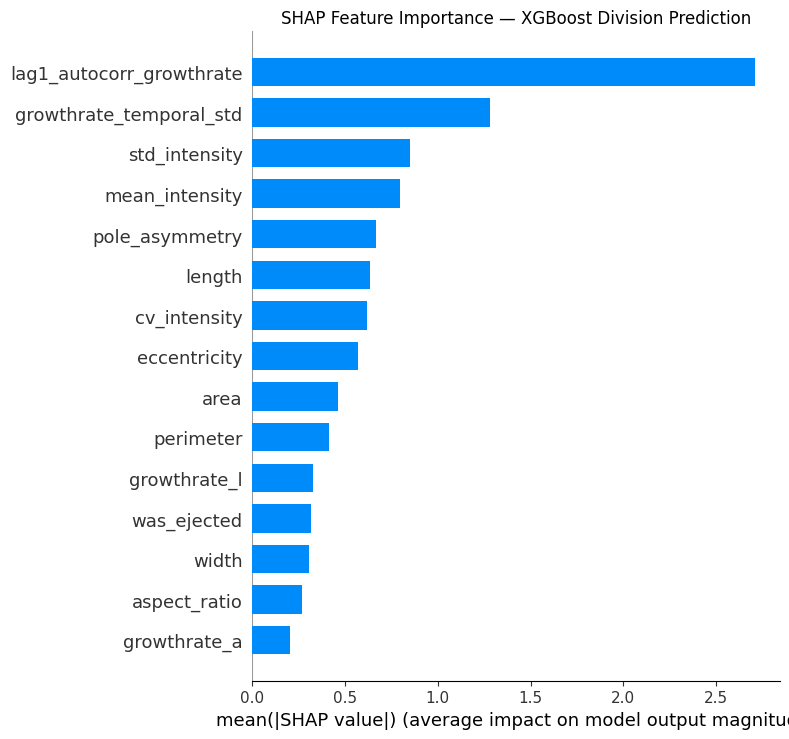

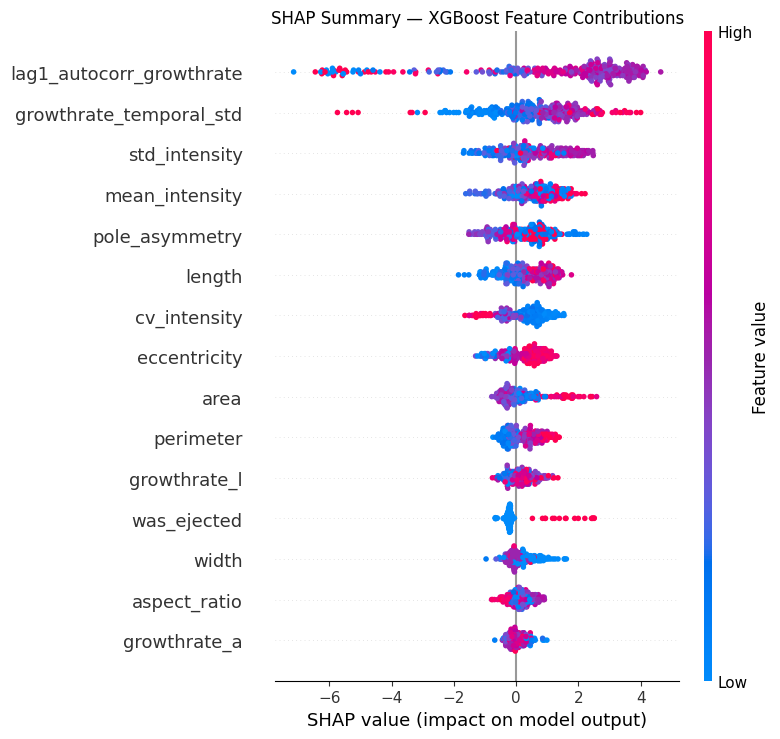


=== SHAP FEATURE RANKING (XGBoost) ===
   1. lag1_autocorr_growthrate            2.70884
   2. growthrate_temporal_std             1.27900
   3. std_intensity                       0.85088
   4. mean_intensity                      0.79840
   5. pole_asymmetry                      0.66513
   6. length                              0.63244
   7. cv_intensity                        0.61675
   8. eccentricity                        0.57057
   9. area                                0.46018
  10. perimeter                           0.41147
  11. growthrate_l                        0.32483
  12. was_ejected                         0.31571
  13. width                               0.30425
  14. aspect_ratio                        0.26660
  15. growthrate_a                        0.20455


In [10]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ── Re-fit XGBoost with SMOTE on scaled data (mirrors the pipeline exactly) ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

clf = xgb.XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
clf.fit(X_train_res, y_train_res)

# ── SHAP TreeExplainer ────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_scaled)

# XGBoost binary: shap_values is a 2D array directly (not a list)
sv = shap_values if not isinstance(shap_values, list) else shap_values[1]

feature_names = FEATURE_COLS

# 1. Global bar chart
shap.summary_plot(sv, X_test_scaled, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost Division Prediction')
plt.tight_layout()
plt.savefig('../outputs/figures/week4_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Beeswarm plot
shap.summary_plot(sv, X_test_scaled, feature_names=feature_names, show=False)
plt.title('SHAP Summary — XGBoost Feature Contributions')
plt.tight_layout()
plt.savefig('../outputs/figures/week4_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Ranked numerical importance
mean_abs_shap = np.abs(sv).mean(axis=0)
ranked = sorted(zip(feature_names, mean_abs_shap), key=lambda x: -x[1])
print("\n=== SHAP FEATURE RANKING (XGBoost) ===")
for rank, (feat, val) in enumerate(ranked, 1):
    print(f"  {rank:2d}. {feat:<35s} {val:.5f}")

In [18]:
from sklearn.utils import resample

n_bootstraps = 150
bootstrap_rankings = []

for seed in range(n_bootstraps):
    X_b, y_b = resample(X_train_scaled, y_train, random_state=seed, stratify=y_train)
    clf_b = xgb.XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
    clf_b.fit(X_b, y_b)
    exp_b = shap.TreeExplainer(clf_b)
    sv_b  = exp_b.shap_values(X_test_scaled)
    sv_b  = sv_b[1] if isinstance(sv_b, list) else sv_b
    mean_abs_b = np.abs(sv_b).mean(axis=0)
    top5 = set(np.argsort(mean_abs_b)[-5:])
    bootstrap_rankings.append(top5)

# Jaccard similarity of top-5 across bootstrap runs
from itertools import combinations

jaccard_scores = []
for a, b in combinations(bootstrap_rankings, 2):
    j = len(a & b) / len(a | b)
    jaccard_scores.append(j)

print(f"Top-5 SHAP stability (Jaccard similarity):")
print(f"  Mean: {np.mean(jaccard_scores):.3f}")
print(f"  Std:  {np.std(jaccard_scores):.3f}")
print(f"\nFeatures in top-5 across all 150 bootstraps:")
from collections import Counter
all_top5 = [feat for ranking in bootstrap_rankings for feat in ranking]
freq = Counter(all_top5)
for feat_idx, count in freq.most_common():
    print(f"  {feature_names[feat_idx]:<35s} appeared in top-5: {count}/150 times")

Top-5 SHAP stability (Jaccard similarity):
  Mean: 0.602
  Std:  0.173

Features in top-5 across all 150 bootstraps:
  lag1_autocorr_growthrate            appeared in top-5: 150/150 times
  growthrate_temporal_std             appeared in top-5: 150/150 times
  std_intensity                       appeared in top-5: 131/150 times
  mean_intensity                      appeared in top-5: 78/150 times
  pole_asymmetry                      appeared in top-5: 76/150 times
  perimeter                           appeared in top-5: 75/150 times
  aspect_ratio                        appeared in top-5: 53/150 times
  cv_intensity                        appeared in top-5: 19/150 times
  length                              appeared in top-5: 17/150 times
  growthrate_l                        appeared in top-5: 1/150 times
